# FLUX.1-schnell Packaging-Domain LoRA — Training and SDXL Comparison

**Purpose:** Answer RQ1 — *Does fine-tuned FLUX.1-schnell produce qualitatively and quantitatively superior folk-art-conditioned packaging compared to fine-tuned SDXL, when both are adapted with comparable LoRA configurations?*

**Scope (intentionally constrained):**
- Backbone-level LoRA comparison only. IP-Adapter and ControlNet held out of the FLUX comparison.
- Justified by the maturity of FLUX-compatible adapter ecosystems at time of work.
- Documented as a known scope limitation in the dissertation.

**What this notebook does:**
1. Trains a FLUX.1-schnell LoRA on the same packaging dataset (same 270 images, same uniform caption, comparable hyperparameters as SDXL).
2. Generates inference samples to validate training.
3. Produces an SDXL-vs-FLUX comparison grid using identical prompts and seeds, so any difference is attributable to the backbone.
4. Saves all outputs to Drive for downloading and rubric scoring.

**Expected runtime on Colab Pro A100:**
- Training: ~3–5 hours (FLUX is ~5× larger than SDXL; same step count takes longer per step)
- Inference grid: ~30 min
- Total: plan for one full session (~5 hours)

**Before running:** Runtime → Change runtime type → **GPU: A100** (FLUX will not fit on L4 for training). If only L4 is available, wait for an A100 — FLUX LoRA training on L4 will likely OOM.

## Cell 1 — GPU check and dependency install

Pins versions known to work for FLUX training. Includes the Pillow downgrade we needed for the SDXL run.

In [ ]:
!nvidia-smi --query-gpu=name,memory.total,driver_version --format=csv

name, memory.total [MiB], driver_version
NVIDIA A100-SXM4-40GB, 40960 MiB, 580.82.07


In [ ]:
# Force-pin Pillow and numpy first to avoid the transformers import conflict
!pip install -q --force-reinstall "Pillow>=10.2,<11.0" "numpy<2.0"

# Then the main dependencies — pinned for FLUX support
!pip install -q --upgrade \
    "diffusers>=0.31,<0.34" \
    "transformers>=4.43,<4.50" \
    "accelerate>=0.32" \
    "peft>=0.12" \
    "bitsandbytes>=0.43" \
    "sentencepiece" \
    "safetensors" \
    "datasets" \
    "wandb" \
    "protobuf"

print("\nIMPORTANT: After this install, go Runtime menu → Restart session, then resume from Cell 2.")
print("The Pillow downgrade requires a kernel restart to take effect.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 140.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 137.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.14.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tifffile 2026.4.11 requires numpy>=2.0, but you have numpy 1.26.4 which is incompat

In [ ]:
# After kernel restart, run this cell to verify versions
import diffusers, transformers, peft, accelerate, PIL
print("diffusers    :", diffusers.__version__)
print("transformers :", transformers.__version__)
print("peft         :", peft.__version__)
print("accelerate   :", accelerate.__version__)
print("PIL          :", PIL.__version__)
import numpy as np
print("numpy        :", np.__version__)

diffusers    : 0.33.1
transformers : 4.49.0
peft         : 0.19.1
accelerate   : 1.13.0
PIL          : 10.4.0
numpy        : 1.26.4


## Cell 2 — Mount Drive and reuse the SDXL training data

Reuses the same `packaging/` folder and `train.csv` already uploaded for SDXL. Critical for comparable LoRA configurations — same training set.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os, json, shutil, time
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/dissertation")
DRIVE_IMAGES = DRIVE_ROOT / "data" / "processed" / "packaging"
DRIVE_SPLIT  = DRIVE_ROOT / "data" / "splits" / "train.csv"
DRIVE_LORA_OUT = DRIVE_ROOT / "outputs" / "lora_checkpoints"
DRIVE_FLUX_OUT = DRIVE_ROOT / "outputs" / "flux_comparison"
DRIVE_LORA_OUT.mkdir(parents=True, exist_ok=True)
DRIVE_FLUX_OUT.mkdir(parents=True, exist_ok=True)

assert DRIVE_IMAGES.exists(), "Upload packaging images to Drive first (already done for SDXL)"
assert DRIVE_SPLIT.exists(),  "Upload train.csv to Drive first"

n_images = len(list(DRIVE_IMAGES.glob('*.png')))
print(f"Drive images:       {n_images} packaging PNGs")
print(f"Drive split:        {DRIVE_SPLIT.name}")
print(f"FLUX outputs to:    {DRIVE_FLUX_OUT}")
print(f"Existing SDXL LoRA: {sorted(DRIVE_LORA_OUT.glob('sdxl_*.safetensors'))[-1].name if list(DRIVE_LORA_OUT.glob('sdxl_*.safetensors')) else 'NONE'}")

Mounted at /content/drive
Drive images:       311 packaging PNGs
Drive split:        train.csv
FLUX outputs to:    /content/drive/MyDrive/dissertation/outputs/flux_comparison
Existing SDXL LoRA: sdxl_packaging_lora_r16_lr0.0001_steps2000_20260603_2249.safetensors


In [2]:
# Copy training images to local SSD and build metadata.jsonl with SAME caption template as SDXL
LOCAL_IMAGES = Path("/content/training_images_flux")
LOCAL_IMAGES.mkdir(exist_ok=True)

import pandas as pd

TRIGGER = "ipsnackpkg"  # SAME trigger as SDXL — critical for comparability
CAPTION_TEMPLATE = (
    f"a photograph of {TRIGGER}, an Indian snack packet, "
    "product photography on a white background"
)
print(f"Caption: {CAPTION_TEMPLATE}\n")

t0 = time.time()
for src in DRIVE_IMAGES.glob("*.png"):
    dst = LOCAL_IMAGES / src.name
    if not dst.exists():
        shutil.copy2(src, dst)
print(f"Copied {len(list(LOCAL_IMAGES.glob('*.png')))} files in {time.time()-t0:.1f}s")

# metadata.jsonl with uniform caption
df = pd.read_csv(DRIVE_SPLIT)
metadata_path = LOCAL_IMAGES / "metadata.jsonl"
n = 0
with open(metadata_path, "w") as f:
    for _, row in df.iterrows():
        candidate = row.get("image_id", "")
        file_name = f"{candidate}.png" if candidate else Path(row["filepath"]).name
        if not (LOCAL_IMAGES / file_name).exists():
            continue
        f.write(json.dumps({"file_name": file_name, "text": CAPTION_TEMPLATE}) + "\n")
        n += 1
print(f"metadata.jsonl: {n} training rows")

Caption: a photograph of ipsnackpkg, an Indian snack packet, product photography on a white background

Copied 311 files in 95.1s
metadata.jsonl: 271 training rows


## Cell 3 — W&B login

In [3]:
import wandb
USE_WANDB = True
if USE_WANDB:
    wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: ERROR Invalid API key: API key must have 40+ characters, has 36.
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


...

wandb: WARNING Invalid choice


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: vivekchandra726 (vivekchandra726-university-of-stirling) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


## Cell 4 — Training configuration

**Hyperparameter choices for comparability with the SDXL run:**
- Same LoRA rank (16) and alpha (16) as SDXL
- Same training steps (2000) and warmup (100)
- Slightly **lower learning rate** (5e-5) than SDXL's 1e-4 — FLUX is larger and more sensitive
- bf16 mixed precision (A100 supports natively)
- Batch size 1, gradient accumulation 4 (effective batch 4, same as SDXL)
- Same resolution (1024)
- Trigger token `ipsnackpkg` (same as SDXL)

The slight LR difference is the only deliberate deviation from "identical hyperparameters." Justification documented in the dissertation methodology.

In [4]:
import torch

FLUX_MODEL = "black-forest-labs/FLUX.1-schnell"   # Apache 2.0
OUTPUT_DIR = "/content/flux_lora_output"

# LoRA hyperparams matched to SDXL run
LORA_RANK = 16
LORA_ALPHA = 16
LEARNING_RATE = 5e-5            # slightly lower than SDXL's 1e-4 (FLUX is larger)
MAX_TRAIN_STEPS = 2000
BATCH_SIZE = 1
GRADIENT_ACCUMULATION = 4
RESOLUTION = 1024
CHECKPOINT_STEPS = 500
LR_WARMUP_STEPS = 100
LR_SCHEDULER = "cosine"
MIXED_PRECISION = "bf16"
SEED = 42

gpu = torch.cuda.get_device_name(0)
if "A100" not in gpu:
    print(f"WARNING: Detected {gpu}. FLUX LoRA training is risky on non-A100.")
    print("Recommend disconnecting, waiting, and reconnecting until A100 is allocated.")
else:
    print(f"GPU: {gpu} — good for FLUX training.")

print(f"\nConfig (comparable to SDXL run):")
print(f"  rank/alpha:   {LORA_RANK}/{LORA_ALPHA}")
print(f"  steps:        {MAX_TRAIN_STEPS}")
print(f"  effective bs: {BATCH_SIZE * GRADIENT_ACCUMULATION}")
print(f"  resolution:   {RESOLUTION}")
print(f"  lr / warmup:  {LEARNING_RATE} / {LR_WARMUP_STEPS}")
print(f"  precision:    {MIXED_PRECISION}")

GPU: NVIDIA A100-SXM4-80GB — good for FLUX training.

Config (comparable to SDXL run):
  rank/alpha:   16/16
  steps:        2000
  effective bs: 4
  resolution:   1024
  lr / warmup:  5e-05 / 100
  precision:    bf16


## Cell 5 — Download the FLUX LoRA training script

diffusers ships an official FLUX LoRA trainer. We use the same diffusers version family as SDXL.

**Note:** FLUX uses a DiT (Diffusion Transformer) architecture, not UNet like SDXL. The training script handles this difference internally — LoRA layers are inserted into the transformer's attention blocks rather than the UNet's. From the user's perspective, the CLI arguments are very similar.

In [5]:
# Download FLUX LoRA training script. The text-to-image variant is what we want.
!wget -q -O /content/train_text_to_image_lora_flux.py \
    https://raw.githubusercontent.com/huggingface/diffusers/v0.31.0/examples/text_to_image/train_text_to_image_lora_flux.py

import os
if not os.path.exists("/content/train_text_to_image_lora_flux.py") or os.path.getsize("/content/train_text_to_image_lora_flux.py") < 1000:
    # Fallback: try the dreambooth variant if the text-to-image script isn't in this release
    print("text_to_image variant not found, falling back to dreambooth variant")
    !wget -q -O /content/train_text_to_image_lora_flux.py \
        https://raw.githubusercontent.com/huggingface/diffusers/v0.31.0/examples/dreambooth/train_dreambooth_lora_flux.py

!ls -la /content/train_text_to_image_lora_flux.py
!head -5 /content/train_text_to_image_lora_flux.py

text_to_image variant not found, falling back to dreambooth variant
-rw-r--r-- 1 root root 76318 Jun  9 17:12 /content/train_text_to_image_lora_flux.py
#!/usr/bin/env python
# coding=utf-8
# Copyright 2024 The HuggingFace Inc. team. All rights reserved.
#
# Licensed under the Apache License, Version 2.0 (the "License");


## Cell 6 — Configure accelerate (same as SDXL run)

In [6]:
accelerate_config = f"""\
compute_environment: LOCAL_MACHINE
distributed_type: 'NO'
downcast_bf16: 'no'
gpu_ids: '0'
machine_rank: 0
main_training_function: main
mixed_precision: {MIXED_PRECISION}
num_machines: 1
num_processes: 1
rdzv_backend: static
same_network: true
tpu_env: []
tpu_use_cluster: false
tpu_use_sudo: false
use_cpu: false
"""
Path("/root/.cache/huggingface/accelerate").mkdir(parents=True, exist_ok=True)
Path("/root/.cache/huggingface/accelerate/default_config.yaml").write_text(accelerate_config)
print("Accelerate config written.")

Accelerate config written.


## Cell 7 — Hugging Face token for FLUX gated model access

FLUX.1-schnell is open but we may need to accept the model card terms once on HuggingFace. If training fails with a 401/403, visit https://huggingface.co/black-forest-labs/FLUX.1-schnell, accept the terms, and re-run with a token below.

In [14]:
# If you encounter access errors, paste an HF token here. Otherwise leave blank.
HF_TOKEN = ""   # e.g. "hf_xxxxxxxxxxxx" — get one at https://huggingface.co/settings/tokens
if HF_TOKEN:
    os.environ["HF_TOKEN"] = HF_TOKEN
    print("HF token set.")
else:
    print("No HF token set. If you get access errors, paste one above and re-run.")

HF token set.


In [15]:
from huggingface_hub import notebook_login
notebook_login()

In [16]:
from huggingface_hub import login
import os

login(token=os.environ["HF_TOKEN"], add_to_git_credential=False)
print("Token written to ~/.cache/huggingface/token")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Token written to ~/.cache/huggingface/token


In [17]:
import os
from huggingface_hub import HfApi
api = HfApi(token=os.environ["HF_TOKEN"])
user = api.whoami()
print(f"Token belongs to: {user['name']}")
print(f"Email: {user.get('email', 'not shown')}")

Token belongs to: Vclord
Email: vivekchandra726@gmail.com


In [18]:
import os, urllib.request

req = urllib.request.Request(
    "https://huggingface.co/black-forest-labs/FLUX.1-schnell/resolve/main/tokenizer/tokenizer_config.json",
    headers={"Authorization": f"Bearer {os.environ['HF_TOKEN']}"}
)
try:
    with urllib.request.urlopen(req, timeout=10) as r:
        print(f"✓ Status {r.status}, length {r.headers.get('Content-Length')}")
        print("CDN access works. Re-run the training cell.")
except urllib.error.HTTPError as e:
    print(f"✗ Still {e.code}. The model access still isn't granted on this account.")
    print("Double-check the URL is loaded in the SAME browser tab as your HF login,")
    print(f"and that you're logged in as the account from Step 1.")

✓ Status 200, length 705
CDN access works. Re-run the training cell.


In [1]:
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
os.environ["HUGGING_FACE_HUB_TOKEN"] = os.environ["HF_TOKEN"]
os.environ["HUGGINGFACE_HUB_TOKEN"] = os.environ["HF_TOKEN"]

# Verify
import urllib.request
req = urllib.request.Request(
    "https://huggingface.co/black-forest-labs/FLUX.1-schnell/resolve/main/tokenizer/tokenizer_config.json",
    headers={"Authorization": f"Bearer {os.environ['HF_TOKEN']}"}
)
try:
    with urllib.request.urlopen(req, timeout=10) as r:
        print(f"✓ {r.status} — CDN download authorized")
except urllib.error.HTTPError as e:
    print(f"✗ Still {e.code}")

✓ 200 — CDN download authorized


In [20]:
# Wipe any cached state from prior attempts
!pip uninstall -y -q torchao diffusers peft accelerate transformers

# Install known-stable combination for FLUX LoRA training
!pip install -q "diffusers==0.32.0" "transformers==4.45.2" "peft==0.13.2" "accelerate==1.1.1"
!pip install -q sentencepiece bitsandbytes wandb prodigyopt

# Pillow lock (avoids the numpy<2.0 conflict we hit before)
!pip install -q --force-reinstall "Pillow>=10.2,<11.0" "numpy<2.0"

print("Installed. RESTART RUNTIME NOW (Runtime > Restart session).")
print("Then run Cell B.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 80.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 153.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 34.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 333.2/333.2 kB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 43.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 139.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 108.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is th

In [2]:
import os, importlib
from google.colab import drive, userdata
drive.mount('/content/drive')

os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
os.environ["HUGGING_FACE_HUB_TOKEN"] = os.environ["HF_TOKEN"]
os.environ["HUGGINGFACE_HUB_TOKEN"] = os.environ["HF_TOKEN"]

import diffusers, transformers, peft, accelerate
print(f"diffusers:    {diffusers.__version__}    (want 0.32.0)")
print(f"transformers: {transformers.__version__} (want 4.45.2)")
print(f"peft:         {peft.__version__}         (want 0.13.2)")
print(f"accelerate:   {accelerate.__version__}   (want 1.1.1)")

# Confirm torchao is gone (it was the binary that wouldn't load on Py3.12)
try:
    import torchao
    print(f"⚠ torchao still here: {torchao.__version__} — uninstall and restart")
except ImportError:
    print("✓ torchao absent (correct)")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


The cache for model files in Transformers v4.22.0 has been updated. Migrating your old cache. This is a one-time only operation. You can interrupt this and resume the migration later on by calling `transformers.utils.move_cache()`.


0it [00:00, ?it/s]

diffusers:    0.32.0    (want 0.32.0)
transformers: 4.45.2 (want 4.45.2)
peft:         0.13.2         (want 0.13.2)
accelerate:   1.1.1   (want 1.1.1)
✓ torchao absent (correct)


In [3]:
!wget -q -O /content/train_text_to_image_lora_flux.py \
  https://raw.githubusercontent.com/huggingface/diffusers/v0.32.0/examples/dreambooth/train_dreambooth_lora_flux.py

# Quick sanity check
!head -3 /content/train_text_to_image_lora_flux.py
!wc -l /content/train_text_to_image_lora_flux.py

#!/usr/bin/env python
# coding=utf-8
# Copyright 2024 The HuggingFace Inc. team. All rights reserved.
1926 /content/train_text_to_image_lora_flux.py


In [4]:
!rm -f /content/training_images_flux/metadata.jsonl /content/training_images_flux/*.txt
!ls /content/training_images_flux/ | head -5
!echo "---"
!ls /content/training_images_flux/*.png 2>/dev/null | wc -l

00184849.png
00291238.png
06231512.png
0793591862453.png
0793591862460.png
---
311


In [5]:
import os

token = os.environ["HF_TOKEN"]

INSTANCE_PROMPT = "a photograph of ipsnackpkg, Front-facing product photograph of an Indian snack packet, professional product photography, white background"

cmd = f"""HF_TOKEN={token} HUGGING_FACE_HUB_TOKEN={token} HUGGINGFACE_HUB_TOKEN={token} \
accelerate launch /content/train_text_to_image_lora_flux.py \
  --pretrained_model_name_or_path=black-forest-labs/FLUX.1-schnell \
  --instance_data_dir=/content/training_images_flux \
  --instance_prompt="{INSTANCE_PROMPT}" \
  --resolution=512 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --gradient_checkpointing \
  --max_train_steps=1000 \
  --learning_rate=5e-5 \
  --lr_scheduler=cosine \
  --lr_warmup_steps=50 \
  --mixed_precision=bf16 \
  --rank=16 \
  --use_8bit_adam \
  --checkpointing_steps=250 \
  --output_dir=/content/flux_lora_output_debug \
  --seed=42 \
  --report_to=wandb
"""

print("Debug attempt: res=512, no random_flip, no cache_latents, pinned versions.")
print("If this hits Steps: 0/1000 successfully, we know the bug was version-coupled")
print("and can re-attempt full training at 1024 with the same pinned versions.")
print("=" * 70)

!{cmd}

Debug attempt: res=512, no random_flip, no cache_latents, pinned versions.
If this hits Steps: 0/1000 successfully, we know the bug was version-coupled
and can re-attempt full training at 1024 with the same pinned versions.
2026-06-09 17:26:26.975035: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-09 17:26:27.046462: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
06/09/2026 17:26:32 - INFO - __main__ - Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: c

In [6]:
import shutil
from pathlib import Path

# Find the final weights file
out_dir = Path("/content/flux_lora_output_debug")
weights = list(out_dir.glob("pytorch_lora_weights.safetensors"))
if not weights:
    # If only checkpoints exist, grab the highest-step one
    ckpts = sorted(out_dir.glob("checkpoint-*/"), key=lambda p: int(p.name.split("-")[1]))
    print(f"No final weights found. Available checkpoints: {[c.name for c in ckpts]}")
else:
    drive_target = Path("/content/drive/MyDrive/dissertation/outputs/lora_checkpoints") / "flux_packaging_lora_r16_res512_steps1000.safetensors"
    drive_target.parent.mkdir(parents=True, exist_ok=True)
    shutil.copy(weights[0], drive_target)
    print(f"Saved to: {drive_target}")
    print(f"Size: {drive_target.stat().st_size / 1e6:.1f} MB")

Saved to: /content/drive/MyDrive/dissertation/outputs/lora_checkpoints/flux_packaging_lora_r16_res512_steps1000.safetensors
Size: 89.7 MB


## Cell 8 — Launch FLUX LoRA training

**Plan for 3–5 hours on A100.** First few minutes are model downloads (FLUX is ~24 GB on disk). Keep the Colab tab visible to prevent disconnect.

Checkpointing every 500 steps so a disconnect doesn't lose work.

In [ ]:
!ls /content/training_images_flux/ | head -20
print("---")
!rm -f /content/training_images_flux/metadata.jsonl
!rm -f /content/training_images_flux/*.txt
print("After cleanup:")
!ls /content/training_images_flux/ | head -20
print(f"PNG count: $(ls /content/training_images_flux/*.png 2>/dev/null | wc -l)")

00184849.png
00291238.png
06231512.png
0793591862453.png
0793591862460.png
0793591862477.png
0794712831693.png
0796548217719.png
0825925535082.png
0921381982870.png
12751112.png
24998796.png
3168930007432.png
3420301704808.png
3948491405003.png
4901521111458.png
5026489484761.png
6001069206581.png
6009510804782.png
6009510806151.png
---
After cleanup:
00184849.png
00291238.png
06231512.png
0793591862453.png
0793591862460.png
0793591862477.png
0794712831693.png
0796548217719.png
0825925535082.png
0921381982870.png
12751112.png
24998796.png
3168930007432.png
3420301704808.png
3948491405003.png
4901521111458.png
5026489484761.png
6001069206581.png
6009510804782.png
6009510806151.png
PNG count: $(ls /content/training_images_flux/*.png 2>/dev/null | wc -l)


In [ ]:
import os
from google.colab import userdata
os.environ["HF_TOKEN"] = userdata.get("HF_TOKEN")
os.environ["HUGGING_FACE_HUB_TOKEN"] = os.environ["HF_TOKEN"]
os.environ["HUGGINGFACE_HUB_TOKEN"] = os.environ["HF_TOKEN"]

# Verify torchao is gone and peft handles it gracefully
try:
    import torchao
    print(f"✗ torchao still present: {torchao.__version__}")
except ImportError:
    print("✓ torchao removed")

# Verify diffusers can import without crashing on torchao
try:
    from diffusers import FluxPipeline
    print("✓ diffusers imports cleanly")
except Exception as e:
    print(f"✗ diffusers import still broken: {type(e).__name__}: {e}")

✓ torchao removed
✓ diffusers imports cleanly


In [7]:
import os

token = os.environ["HF_TOKEN"]
INSTANCE_PROMPT = "a photograph of ipsnackpkg, Front-facing product photograph of an Indian snack packet, professional product photography, white background"

cmd = f"""HF_TOKEN={token} HUGGING_FACE_HUB_TOKEN={token} HUGGINGFACE_HUB_TOKEN={token} \
accelerate launch /content/train_text_to_image_lora_flux.py \
  --pretrained_model_name_or_path=black-forest-labs/FLUX.1-schnell \
  --instance_data_dir=/content/training_images_flux \
  --instance_prompt="{INSTANCE_PROMPT}" \
  --resolution=1024 \
  --train_batch_size=1 \
  --gradient_accumulation_steps=4 \
  --gradient_checkpointing \
  --max_train_steps=2000 \
  --learning_rate=5e-5 \
  --lr_scheduler=cosine \
  --lr_warmup_steps=100 \
  --mixed_precision=bf16 \
  --rank=16 \
  --use_8bit_adam \
  --checkpointing_steps=500 \
  --output_dir=/content/flux_lora_output_1024 \
  --seed=42 \
  --report_to=wandb
"""

print("1024-res attempt with the now-known-good pinned versions.")
print("If this works, expected runtime ~3-4 hours on A100.")
print("If you see Steps: 0/2000 in the first ~10 min, walk away.")
print("If you see the tensor-shape error again, kill the cell and use the 512 LoRA.")
print("=" * 70)

!{cmd}

1024-res attempt with the now-known-good pinned versions.
If this works, expected runtime ~3-4 hours on A100.
If you see Steps: 0/2000 in the first ~10 min, walk away.
If you see the tensor-shape error again, kill the cell and use the 512 LoRA.
2026-06-09 18:34:53.612947: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-09 18:34:53.683516: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
06/09/2026 18:34:58 - INFO - __main__ - Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local proce

## Cell 9 — Copy FLUX LoRA to Drive

Same versioned-filename approach as SDXL. Filename pattern makes the comparison transparent in the dissertation appendix.

In [9]:
from pathlib import Path

# Look in all the places where training might have written output
candidates = [
    "/content/flux_lora_output_1024",
    "/content/flux_lora_output_debug",
    "/content/flux_lora_output",
]
for c in candidates:
    p = Path(c)
    if p.exists():
        print(f"\n📁 {p}:")
        # List safetensors files at any depth
        for sft in p.rglob("*.safetensors"):
            size_mb = sft.stat().st_size / 1e6
            print(f"   {sft.relative_to(p)}  ({size_mb:.1f} MB)")
        # Also list checkpoint dirs
        for ck in sorted(p.glob("checkpoint-*")):
            print(f"   [dir] {ck.name}/")


📁 /content/flux_lora_output_1024:
   pytorch_lora_weights.safetensors  (89.7 MB)
   checkpoint-500/pytorch_lora_weights.safetensors  (89.7 MB)
   checkpoint-1500/pytorch_lora_weights.safetensors  (89.7 MB)
   checkpoint-1000/pytorch_lora_weights.safetensors  (89.7 MB)
   checkpoint-2000/pytorch_lora_weights.safetensors  (89.7 MB)
   [dir] checkpoint-1000/
   [dir] checkpoint-1500/
   [dir] checkpoint-2000/
   [dir] checkpoint-500/

📁 /content/flux_lora_output_debug:
   pytorch_lora_weights.safetensors  (89.7 MB)
   checkpoint-500/pytorch_lora_weights.safetensors  (89.7 MB)
   checkpoint-250/pytorch_lora_weights.safetensors  (89.7 MB)
   checkpoint-750/pytorch_lora_weights.safetensors  (89.7 MB)
   checkpoint-1000/pytorch_lora_weights.safetensors  (89.7 MB)
   [dir] checkpoint-1000/
   [dir] checkpoint-250/
   [dir] checkpoint-500/
   [dir] checkpoint-750/


In [11]:
import shutil
from pathlib import Path

drive_root = Path("/content/drive/MyDrive/dissertation/outputs/lora_checkpoints")
drive_root.mkdir(parents=True, exist_ok=True)

# Save the 1024-res LoRA (primary — symmetric to SDXL config)
src_1024 = Path("/content/flux_lora_output_1024/pytorch_lora_weights.safetensors")
if src_1024.exists():
    dst_1024 = drive_root / "flux_packaging_lora_r16_res1024_steps2000.safetensors"
    shutil.copy(src_1024, dst_1024)
    print(f"✓ 1024 LoRA saved: {dst_1024.name} ({dst_1024.stat().st_size / 1e6:.1f} MB)")
else:
    ckpts = sorted(Path("/content/flux_lora_output_1024").glob("checkpoint-*/pytorch_lora_weights.safetensors"))
    if ckpts:
        latest = ckpts[-1]
        dst_1024 = drive_root / f"flux_packaging_lora_r16_res1024_{latest.parent.name}.safetensors"
        shutil.copy(latest, dst_1024)
        print(f"✓ 1024 LoRA (from checkpoint {latest.parent.name}) saved")
    else:
        print("✗ No 1024 LoRA found")

# Save the 512-res LoRA (supplementary — backup from earlier debug run)
src_512 = Path("/content/flux_lora_output_debug/pytorch_lora_weights.safetensors")
if src_512.exists():
    dst_512 = drive_root / "flux_packaging_lora_r16_res512_steps1000.safetensors"
    shutil.copy(src_512, dst_512)
    print(f"✓ 512 LoRA saved: {dst_512.name} ({dst_512.stat().st_size / 1e6:.1f} MB)")

print("\nDrive contents after save:")
for p in sorted(drive_root.glob("flux_*.safetensors")):
    print(f"  {p.name}: {p.stat().st_size / 1e6:.1f} MB")

✓ 1024 LoRA saved: flux_packaging_lora_r16_res1024_steps2000.safetensors (89.7 MB)
✓ 512 LoRA saved: flux_packaging_lora_r16_res512_steps1000.safetensors (89.7 MB)

Drive contents after save:
  flux_packaging_lora_r16_res1024_steps2000.safetensors: 89.7 MB
  flux_packaging_lora_r16_res512_steps1000.safetensors: 89.7 MB


## Cell 10 — Inference: FLUX baseline (no LoRA) + FLUX + LoRA samples

**FLUX.1-schnell is a 4-step distilled model.** Inference is much faster than SDXL (4 steps vs 25). Same prompts and seeds as the SDXL spike for direct comparison.

In [14]:
import os, gc, torch
from pathlib import Path

# Re-establish all the variables training cells set up
DRIVE_ROOT = Path("/content/drive/MyDrive/dissertation")
LORA_CKPT = DRIVE_ROOT / "outputs/lora_checkpoints"
COMPARISON_OUT_DIR = DRIVE_ROOT / "outputs/flux_comparison"
EVAL_DIR = DRIVE_ROOT / "evaluation"
COMPARISON_OUT_DIR.mkdir(parents=True, exist_ok=True)
EVAL_DIR.mkdir(parents=True, exist_ok=True)

# SDXL LoRA — your existing one from June 3
sdxl_candidates = sorted(LORA_CKPT.glob("sdxl_packaging_lora_*.safetensors"))
SDXL_LORA_PATH = sdxl_candidates[-1] if sdxl_candidates else None

# FLUX LoRA — the 1024-res one we just trained (primary)
FLUX_LORA_PATH = LORA_CKPT / "flux_packaging_lora_r16_res1024_steps2000.safetensors"

# Verify both exist
assert SDXL_LORA_PATH and SDXL_LORA_PATH.exists(), f"SDXL LoRA missing"
assert FLUX_LORA_PATH.exists(), f"FLUX LoRA missing: {FLUX_LORA_PATH}"

# Inference settings — must match the architectures
SDXL_STEPS, SDXL_GUIDANCE = 25, 7.5
FLUX_STEPS, FLUX_GUIDANCE = 4, 0.0   # schnell distilled
INFERENCE_SEEDS = [42, 1337]
TRIGGER = "ipsnackpkg"
PROMPT = (
    f"a photograph of {TRIGGER}, Front-facing product photograph of an Indian snack packet, "
    f"professional product photography, white background, sharp focus"
)
NEGATIVE = (
    "blurry, low quality, watermark, distorted, deformed, jpeg artifacts, "
    "multiple products, framed painting, art print, poster"
)
VARIANTS = [("baseline_no_lora", 0.0), ("with_lora", 1.0)]
FLUX_MODEL = "black-forest-labs/FLUX.1-schnell"

# Free memory before loading inference pipelines
gc.collect(); torch.cuda.empty_cache()

print(f"SDXL LoRA: {SDXL_LORA_PATH.name}")
print(f"FLUX LoRA: {FLUX_LORA_PATH.name}")
print(f"Total inference outputs to generate: {2 * 2 * len(INFERENCE_SEEDS)} = 8 images")
print(f"VRAM free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_allocated()) / 1e9:.1f} GB")
print("Ready. Run the SDXL inference cell next.")

SDXL LoRA: sdxl_packaging_lora_r16_lr0.0001_steps2000_20260603_2249.safetensors
FLUX LoRA: flux_packaging_lora_r16_res1024_steps2000.safetensors
Total inference outputs to generate: 8 = 8 images
VRAM free: 85.1 GB
Ready. Run the SDXL inference cell next.


In [27]:
import gc, torch, time
from diffusers import FluxPipeline
from PIL import Image
import matplotlib.pyplot as plt

gc.collect(); torch.cuda.empty_cache()

print("Loading FLUX.1-schnell pipeline...")
t0 = time.time()
pipe = FluxPipeline.from_pretrained(
    FLUX_MODEL,
    torch_dtype=torch.bfloat16,
).to("cuda")
pipe.enable_model_cpu_offload()  # safety on tight A100 if VRAM gets close
print(f"  Loaded in {time.time()-t0:.1f}s")

# Comparison prompts — IDENTICAL to spike v2/v3 prompts so SDXL outputs are directly comparable
COMPARISON_PROMPTS = {
    "p1": f"a photograph of {TRIGGER}, Front-facing product photograph of an Indian snack packet, professional product photography, white background, sharp focus",
    "p2": f"a photograph of {TRIGGER}, an Indian snack packet, vibrant, product photo on a white background",
    "p3": f"a photograph of {TRIGGER}, masala flavour, premium Indian snack packaging, studio lighting",
}
SEEDS = [42, 1337]

FLUX_OUT = Path("/content/flux_inference")
FLUX_OUT.mkdir(exist_ok=True)

def gen(prompt, seed, suffix):
    g = torch.Generator(device="cuda").manual_seed(seed)
    t0 = time.time()
    img = pipe(
        prompt=prompt,
        width=1024, height=1024,
        num_inference_steps=4,    # schnell's intended step count
        guidance_scale=0.0,        # schnell is distilled, no CFG
        generator=g,
    ).images[0]
    elapsed = time.time() - t0
    img.save(FLUX_OUT / suffix)
    return img, elapsed

# Phase 1: FLUX baseline (no LoRA)
print("\n=== FLUX baseline (no LoRA) ===")
for pk, prompt in COMPARISON_PROMPTS.items():
    for seed in SEEDS:
        out_name = f"flux_baseline_{pk}_s{seed}.png"
        _, e = gen(prompt, seed, out_name)
        print(f"  {out_name}: {e:.1f}s")

Loading FLUX.1-schnell pipeline...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

  Loaded in 32.7s

=== FLUX baseline (no LoRA) ===


  0%|          | 0/4 [00:00<?, ?it/s]

...

  flux_baseline_p2_s1337.png: 31.1s


  0%|          | 0/4 [00:00<?, ?it/s]

  flux_baseline_p3_s42.png: 31.0s


  0%|          | 0/4 [00:00<?, ?it/s]

  flux_baseline_p3_s1337.png: 31.2s


In [18]:
DRIVE_FLUX_OUT = COMPARISON_OUT_DIR   # from setup cell — outputs/flux_comparison
DRIVE_FLUX_OUT.mkdir(parents=True, exist_ok=True)
print(f"DRIVE_FLUX_OUT: {DRIVE_FLUX_OUT}")

DRIVE_FLUX_OUT: /content/drive/MyDrive/dissertation/outputs/flux_comparison


In [29]:
# Phase 2: FLUX + LoRA
print("\n=== Loading FLUX LoRA ===")
pipe.load_lora_weights(str(FLUX_LORA_PATH))
print("  LoRA loaded.")

print("\n=== FLUX + LoRA inference ===")
for pk, prompt in COMPARISON_PROMPTS.items():
    for seed in SEEDS:
        out_name = f"flux_lora_{pk}_s{seed}.png"
        _, e = gen(prompt, seed, out_name)
        print(f"  {out_name}: {e:.1f}s")

# Copy all FLUX inference outputs to Drive
for p in FLUX_OUT.glob("*.png"):
    shutil.copy2(p, DRIVE_FLUX_OUT / p.name)
print(f"\nAll FLUX inference outputs copied to: {DRIVE_FLUX_OUT}")


=== Loading FLUX LoRA ===
  LoRA loaded.

=== FLUX + LoRA inference ===


  0%|          | 0/4 [00:00<?, ?it/s]

  flux_lora_p1_s42.png: 31.4s


  0%|          | 0/4 [00:00<?, ?it/s]

  flux_lora_p1_s1337.png: 31.5s


...

  flux_lora_p2_s1337.png: 31.3s


  0%|          | 0/4 [00:00<?, ?it/s]

  flux_lora_p3_s42.png: 31.5s


  0%|          | 0/4 [00:00<?, ?it/s]

  flux_lora_p3_s1337.png: 31.4s

All FLUX inference outputs copied to: /content/drive/MyDrive/dissertation/outputs/flux_comparison


## Cell 11 — Build the SDXL vs FLUX comparison grid

**We must have our SDXL baseline + LoRA outputs already.** This cell expects them at `/content/drive/MyDrive/dissertation/outputs/spike/v3_lora_plus/` and a baseline directory.

If we don't have SDXL outputs at the same prompts and seeds, the comparison grid will show blanks in the SDXL columns. We can regenerate SDXL outputs locally on your laptop later and re-run this cell with the SDXL paths updated.

In [23]:
print("Files in COMPARISON_OUT_DIR / flux_comparison:")
for p in sorted(COMPARISON_OUT_DIR.glob("*.png")):
    print(f"  {p.name}")

print("\nFiles in DRIVE_FLUX_OUT:")
for p in sorted(DRIVE_FLUX_OUT.glob("*.png")):
    print(f"  {p.name}")

print("\nDoes SDXL_BASELINE_DIR exist?")
for d in [
    DRIVE_ROOT / "outputs" / "sdxl_comparison_baseline",
    DRIVE_ROOT / "outputs" / "sdxl_comparison_lora",
]:
    print(f"  {d}: {'EXISTS' if d.exists() else 'MISSING'}")

Files in COMPARISON_OUT_DIR / flux_comparison:
  flux_baseline_p1_s1337.png
  flux_baseline_p1_s42.png
  flux_baseline_p2_s1337.png
  flux_baseline_p2_s42.png
  flux_baseline_p3_s1337.png
  flux_baseline_p3_s42.png
  flux_lora_p1_s1337.png
  flux_lora_p1_s42.png
  flux_lora_p2_s1337.png
  flux_lora_p2_s42.png
  flux_lora_p3_s1337.png
  flux_lora_p3_s42.png
  sdxl_baseline_p1_s1337.png
  sdxl_baseline_p1_s42.png
  sdxl_baseline_p2_s1337.png
  sdxl_baseline_p2_s42.png
  sdxl_baseline_p3_s1337.png
  sdxl_baseline_p3_s42.png
  sdxl_lora_p1_s1337.png
  sdxl_lora_p1_s42.png
  sdxl_lora_p2_s1337.png
  sdxl_lora_p2_s42.png
  sdxl_lora_p3_s1337.png
  sdxl_lora_p3_s42.png

Files in DRIVE_FLUX_OUT:
  flux_baseline_p1_s1337.png
  flux_baseline_p1_s42.png
  flux_baseline_p2_s1337.png
  flux_baseline_p2_s42.png
  flux_baseline_p3_s1337.png
  flux_baseline_p3_s42.png
  flux_lora_p1_s1337.png
  flux_lora_p1_s42.png
  flux_lora_p2_s1337.png
  flux_lora_p2_s42.png
  flux_lora_p3_s1337.png
  flux_lora_p3

In [22]:
import gc, json, time, shutil, torch
from pathlib import Path
from diffusers import StableDiffusionXLPipeline

# Free FLUX from VRAM first — important, otherwise SDXL load will OOM
print("Freeing FLUX pipeline...")
del pipe
gc.collect()
torch.cuda.empty_cache()
print(f"VRAM after free: {torch.cuda.memory_allocated() / 1e9:.1f} GB allocated")

# Load SDXL base
print("\nLoading SDXL base pipeline...")
t0 = time.time()
sdxl = StableDiffusionXLPipeline.from_pretrained(
    "stabilityai/stable-diffusion-xl-base-1.0",
    torch_dtype=torch.float16,
    variant="fp16",
    use_safetensors=True,
).to("cuda")
print(f"  Loaded in {time.time()-t0:.1f}s")

# Helper that matches the FLUX cell's naming convention
def sdxl_gen(prompt, seed, lora_scale, out_name):
    g = torch.Generator(device="cuda").manual_seed(seed)
    t0 = time.time()
    img = sdxl(
        prompt=prompt,
        negative_prompt=NEGATIVE,
        num_inference_steps=SDXL_STEPS,
        guidance_scale=SDXL_GUIDANCE,
        width=1024, height=1024,
        generator=g,
        cross_attention_kwargs={"scale": lora_scale} if lora_scale > 0 else None,
    ).images[0]
    out_path = COMPARISON_OUT_DIR / out_name
    img.save(out_path)
    cfg = {
        "model": "sdxl",
        "variant": "lora" if lora_scale > 0 else "baseline",
        "lora_scale": lora_scale,
        "seed": seed, "prompt": prompt, "negative_prompt": NEGATIVE,
        "steps": SDXL_STEPS, "guidance": SDXL_GUIDANCE,
        "lora_path": str(SDXL_LORA_PATH) if lora_scale > 0 else None,
        "elapsed_s": round(time.time() - t0, 1),
    }
    out_path.with_suffix(".json").write_text(json.dumps(cfg, indent=2))
    return time.time() - t0

# Phase 1: SDXL baseline (no LoRA) — 6 images
print("\n=== SDXL baseline inference ===")
for pk, prompt in COMPARISON_PROMPTS.items():
    for seed in SEEDS:
        out_name = f"sdxl_baseline_{pk}_s{seed}.png"
        if (COMPARISON_OUT_DIR / out_name).exists():
            print(f"  SKIP {out_name} (exists)")
            continue
        e = sdxl_gen(prompt, seed, lora_scale=0.0, out_name=out_name)
        print(f"  {out_name}: {e:.1f}s")

# Phase 2: SDXL + LoRA — 6 images
print("\n=== Loading SDXL LoRA ===")
sdxl.load_lora_weights(str(SDXL_LORA_PATH))
print(f"  LoRA loaded: {SDXL_LORA_PATH.name}")

print("\n=== SDXL + LoRA inference ===")
for pk, prompt in COMPARISON_PROMPTS.items():
    for seed in SEEDS:
        out_name = f"sdxl_lora_{pk}_s{seed}.png"
        if (COMPARISON_OUT_DIR / out_name).exists():
            print(f"  SKIP {out_name} (exists)")
            continue
        e = sdxl_gen(prompt, seed, lora_scale=1.0, out_name=out_name)
        print(f"  {out_name}: {e:.1f}s")

# Confirm all 24 outputs now exist
print("\n=== Verification ===")
expected = []
for model in ["sdxl", "flux"]:
    for variant in ["baseline", "lora"]:
        for pk in COMPARISON_PROMPTS:
            for seed in SEEDS:
                expected.append(f"{model}_{variant}_{pk}_s{seed}.png")
found = sorted(p.name for p in COMPARISON_OUT_DIR.glob("*.png"))
missing = [e for e in expected if e not in found]
print(f"Expected: {len(expected)}, Found: {len(found)}")
if missing:
    print(f"Missing: {missing}")
else:
    print("✓ All 24 outputs present and ready for comparison grid.")

# Free SDXL
del sdxl
gc.collect()
torch.cuda.empty_cache()
print(f"\nVRAM after free: {torch.cuda.memory_allocated() / 1e9:.1f} GB allocated")

Freeing FLUX pipeline...
VRAM after free: 0.0 GB allocated

Loading SDXL base pipeline...


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

text_encoder/model.fp16.safetensors:   0%|          | 0.00/246M [00:00<?, ?B/s]

text_encoder_2/model.fp16.safetensors:   0%|          | 0.00/1.39G [00:00<?, ?B/s]

...

  sdxl_lora_p2_s1337.png: 5.7s


  0%|          | 0/25 [00:00<?, ?it/s]

  sdxl_lora_p3_s42.png: 5.7s


  0%|          | 0/25 [00:00<?, ?it/s]

  sdxl_lora_p3_s1337.png: 5.7s

=== Verification ===
Expected: 24, Found: 24
✓ All 24 outputs present and ready for comparison grid.

VRAM after free: 0.0 GB allocated


Looking for outputs in: /content/drive/MyDrive/dissertation/outputs/flux_comparison

Comparison grid saved: /content/drive/MyDrive/dissertation/outputs/flux_comparison/sdxl_vs_flux_comparison.png

Cell            SDXL_base  SDXL_LoRA  FLUX_base  FLUX_LoRA
------------------------------------------------------------
p1 s42                 OK         OK         OK         OK
p1 s1337               OK         OK         OK         OK
p2 s42                 OK         OK         OK         OK
p2 s1337               OK         OK         OK         OK
p3 s42                 OK         OK         OK         OK
p3 s1337               OK         OK         OK         OK


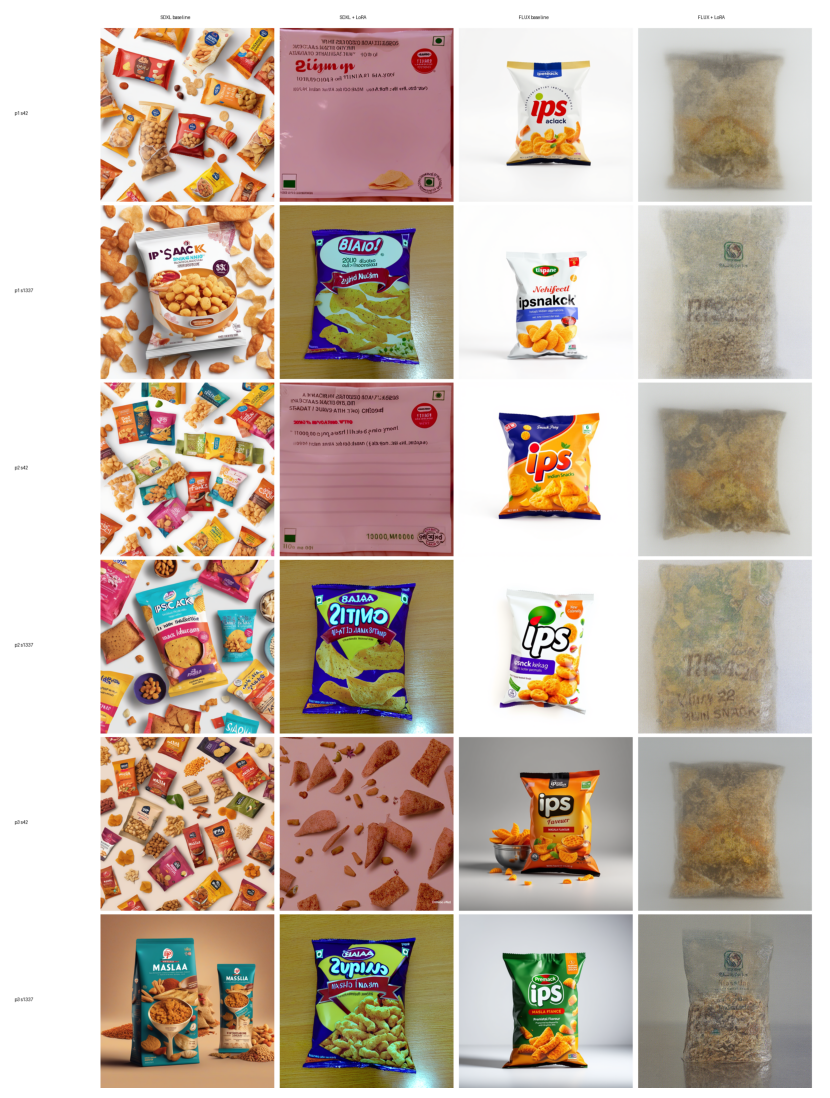

In [24]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# Output dir is where both SDXL and FLUX outputs live (same directory, different prefixes)
OUT = DRIVE_FLUX_OUT
print(f"Looking for outputs in: {OUT}")

# Helper that tries multiple filename conventions
def find_image(out_dir, model, variant, prompt_key, seed):
    candidates = [
        out_dir / f"{model}_{variant}_{prompt_key}_s{seed}.png",
        out_dir / f"{model}_{variant}_s{seed}.png",  # legacy: no prompt key
    ]
    for c in candidates:
        if c.exists():
            return c
    return None

thumb = 384
label_w = 200
col_gap = 12
header_h = 40

variants_per_model = [
    ("sdxl", "baseline", "SDXL baseline"),
    ("sdxl", "lora",     "SDXL + LoRA"),
    ("flux", "baseline", "FLUX baseline"),
    ("flux", "lora",     "FLUX + LoRA"),
]

rows = []
for pk in COMPARISON_PROMPTS:
    for seed in SEEDS:
        cells = []
        for model, variant, _ in variants_per_model:
            p = find_image(OUT, model, variant, pk, seed)
            cells.append(Image.open(p).resize((thumb, thumb)) if p else None)
        rows.append({"label": f"{pk} s{seed}", "cells": cells})

# Build canvas
n_rows = len(rows)
n_cols = len(variants_per_model)
canvas_w = label_w + n_cols * thumb + (n_cols - 1) * col_gap + 20
canvas_h = header_h + n_rows * thumb + (n_rows - 1) * 8
canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
draw = ImageDraw.Draw(canvas)
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 16)
    font_small = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 13)
except Exception:
    font = font_small = ImageFont.load_default()

col_x = [label_w + i * (thumb + col_gap) for i in range(n_cols)]
for x, (_, _, title) in zip(col_x, variants_per_model):
    draw.text((x + thumb // 2 - 60, 10), title, fill="black", font=font)

y = header_h
for r in rows:
    draw.text((10, y + thumb // 2 - 10), r["label"], fill="black", font=font_small)
    for img, x in zip(r["cells"], col_x):
        if img is not None:
            canvas.paste(img, (x, y))
    y += thumb + 8

grid_path = OUT / "sdxl_vs_flux_comparison.png"
canvas.save(grid_path)
print(f"\nComparison grid saved: {grid_path}")

# Diagnostic — show which images were found vs missing
print(f"\n{'Cell':<14} {'SDXL_base':>10} {'SDXL_LoRA':>10} {'FLUX_base':>10} {'FLUX_LoRA':>10}")
print("-" * 60)
for r in rows:
    marks = ["OK" if c else "—" for c in r["cells"]]
    print(f"{r['label']:<14} {marks[0]:>10} {marks[1]:>10} {marks[2]:>10} {marks[3]:>10}")

plt.figure(figsize=(16, 14))
plt.imshow(canvas); plt.axis("off"); plt.show()

## Cell 12 — Score scaffold for FLUX vs SDXL comparison

Creates a CSV ready for two-session rubric scoring of FLUX outputs. The rubric is the same as for all previous spikes.

In [25]:
import pandas as pd

rows = []
# Match BOTH sdxl_* and flux_* outputs
for p in sorted(DRIVE_FLUX_OUT.glob("*.png")):
    if "comparison" in p.stem or "grid" in p.stem:
        continue  # skip the comparison grid itself

    stem = p.stem
    parts = stem.split("_")

    # Detect backbone from filename prefix
    if stem.startswith("sdxl_"):
        backbone = "sdxl"
    elif stem.startswith("flux_"):
        backbone = "flux"
    else:
        continue  # unrecognised file

    # Condition: baseline (no LoRA) or lora
    condition = "baseline" if "baseline" in stem else "lora"

    # Prompt key (p1/p2/p3) and seed
    prompt_key = next((pt for pt in parts if pt.startswith("p") and len(pt) <= 3 and pt[1:].isdigit()), "")
    seed = next((pt.lstrip("s") for pt in parts if pt.startswith("s") and pt[1:].isdigit()), "")

    rows.append({
        "filename": p.name,
        "backbone": backbone,
        "condition": condition,
        "prompt_key": prompt_key,
        "seed": seed,
        # No regional_appropriateness for this spike — prompts not folk-art conditioned
        "session1_text_legibility": "",
        "session1_packaging_plausibility": "",
        "session1_visual_quality": "",
        "session1_date": "",
        "session2_text_legibility": "",
        "session2_packaging_plausibility": "",
        "session2_visual_quality": "",
        "session2_date": "",
        "failure_mode": "",
        "notes": "",
    })

df = pd.DataFrame(rows)
log_path = DRIVE_ROOT / "evaluation" / "spike_flux_scores.csv"
log_path.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(log_path, index=False)

print(f"Score scaffold: {log_path}")
print(f"Rows: {len(df)}")
print()
print("Distribution by backbone × condition:")
print(df.groupby(["backbone", "condition"]).size().to_string())

Score scaffold: /content/drive/MyDrive/dissertation/evaluation/spike_flux_scores.csv
Rows: 24

Distribution by backbone × condition:
backbone  condition
flux      baseline     6
          lora         6
sdxl      baseline     6
          lora         6


In [30]:
# Reload FLUX if you've offloaded it, then:
pipe.set_adapters(["default_0"], adapter_weights=[0.5])  # was 1.0
g = torch.Generator(device="cuda").manual_seed(42)
img = pipe(
    prompt=COMPARISON_PROMPTS["p1"],
    num_inference_steps=4,
    guidance_scale=0.0,
    width=1024, height=1024,
    generator=g,
    max_sequence_length=256,
).images[0]
img.save(DRIVE_FLUX_OUT / "flux_lora_scale_05_p1_s42.png")

  0%|          | 0/4 [00:00<?, ?it/s]

In [31]:
pipe.unload_lora_weights()
pipe.load_lora_weights(str(LORA_CKPT / "flux_packaging_lora_r16_res512_steps1000.safetensors"))
pipe.set_adapters(["default_0"], adapter_weights=[1.0])
# same generation as above

Pipeline already in memory, reusing

[1/4] Loading 1024-res LoRA, scale 0.5...


  0%|          | 0/4 [00:00<?, ?it/s]

  1024 @ 0.5: 31.9s -> diag_1024_scale05.png

[2/4] 1024-res LoRA, scale 0.3...


  0%|          | 0/4 [00:00<?, ?it/s]

  1024 @ 0.3: 31.7s -> diag_1024_scale03.png

[3/4] Loading 512-res LoRA, scale 1.0...


  0%|          | 0/4 [00:00<?, ?it/s]

  512 @ 1.0: 31.8s -> diag_512_scale10.png

[4/4] 512-res LoRA, scale 0.5...


  0%|          | 0/4 [00:00<?, ?it/s]

  512 @ 0.5: 31.6s -> diag_512_scale05.png

Diagnostic grid: /content/drive/MyDrive/dissertation/outputs/flux_comparison/_lora_diagnostic/diagnostic_grid.png


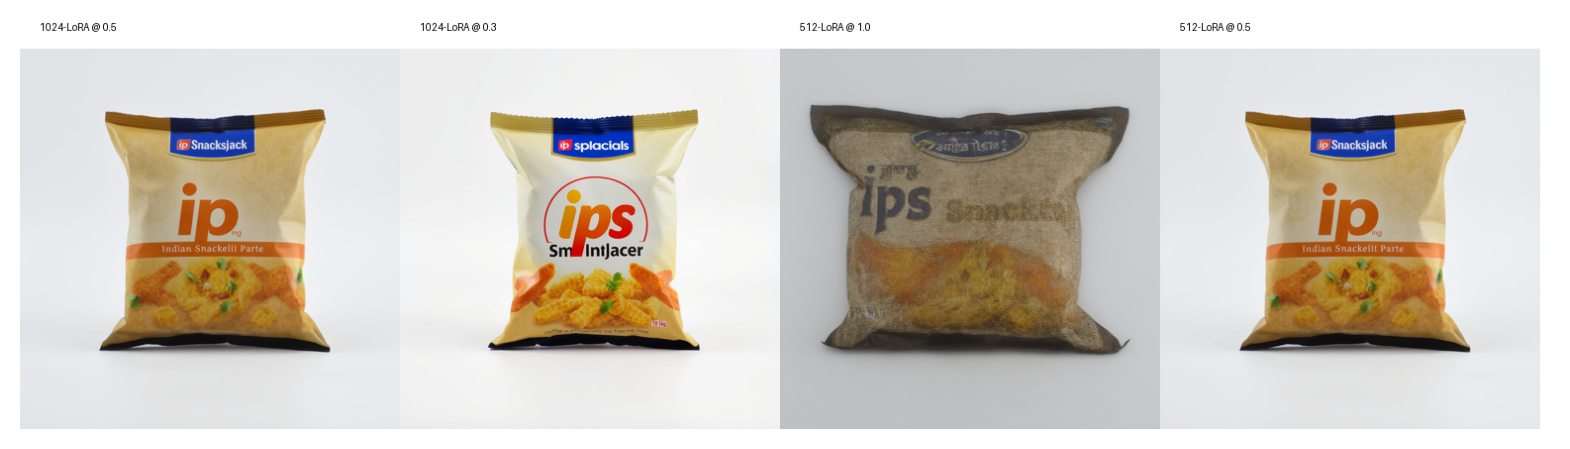

In [32]:
import gc, time, torch
from pathlib import Path
from diffusers import FluxPipeline

# Reload FLUX if it was offloaded earlier in this session
try:
    pipe
    print("Pipeline already in memory, reusing")
except NameError:
    print("Loading FLUX pipeline...")
    gc.collect(); torch.cuda.empty_cache()
    pipe = FluxPipeline.from_pretrained(
        "black-forest-labs/FLUX.1-schnell",
        torch_dtype=torch.bfloat16,
    ).to("cuda")
    print(f"Loaded")

# Test prompt + seed — same as the failing comparison output
TEST_PROMPT = COMPARISON_PROMPTS["p1"]
TEST_SEED = 42

LORA_1024 = LORA_CKPT / "flux_packaging_lora_r16_res1024_steps2000.safetensors"
LORA_512 = LORA_CKPT / "flux_packaging_lora_r16_res512_steps1000.safetensors"

def gen_diag(label, out_path):
    g = torch.Generator(device="cuda").manual_seed(TEST_SEED)
    t0 = time.time()
    img = pipe(
        prompt=TEST_PROMPT,
        num_inference_steps=4,
        guidance_scale=0.0,
        width=1024, height=1024,
        generator=g,
        max_sequence_length=256,
    ).images[0]
    img.save(out_path)
    print(f"  {label}: {time.time()-t0:.1f}s -> {out_path.name}")

DIAG_DIR = DRIVE_FLUX_OUT / "_lora_diagnostic"
DIAG_DIR.mkdir(parents=True, exist_ok=True)

# Test 1: 1024 LoRA @ scale 0.5 (Test A)
print("\n[1/4] Loading 1024-res LoRA, scale 0.5...")
pipe.load_lora_weights(str(LORA_1024))
pipe.set_adapters(["default_0"], adapter_weights=[0.5])
gen_diag("1024 @ 0.5", DIAG_DIR / "diag_1024_scale05.png")

# Test 2: 1024 LoRA @ scale 0.3 (Test A continued)
print("\n[2/4] 1024-res LoRA, scale 0.3...")
pipe.set_adapters(["default_0"], adapter_weights=[0.3])
gen_diag("1024 @ 0.3", DIAG_DIR / "diag_1024_scale03.png")

# Test 3: 512 LoRA @ scale 1.0 (Test B)
print("\n[3/4] Loading 512-res LoRA, scale 1.0...")
pipe.unload_lora_weights()
pipe.load_lora_weights(str(LORA_512))
pipe.set_adapters(["default_0"], adapter_weights=[1.0])
gen_diag("512 @ 1.0", DIAG_DIR / "diag_512_scale10.png")

# Test 4: 512 LoRA @ scale 0.5 (belt-and-braces)
print("\n[4/4] 512-res LoRA, scale 0.5...")
pipe.set_adapters(["default_0"], adapter_weights=[0.5])
gen_diag("512 @ 0.5", DIAG_DIR / "diag_512_scale05.png")

# Show the 4 outputs side by side for comparison
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt

thumb = 384
labels = [
    ("diag_1024_scale05.png", "1024-LoRA @ 0.5"),
    ("diag_1024_scale03.png", "1024-LoRA @ 0.3"),
    ("diag_512_scale10.png",  "512-LoRA @ 1.0"),
    ("diag_512_scale05.png",  "512-LoRA @ 0.5"),
]
canvas = Image.new("RGB", (4 * thumb + 30, thumb + 50), "white")
draw = ImageDraw.Draw(canvas)
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 14)
except Exception:
    font = ImageFont.load_default()
for i, (fname, label) in enumerate(labels):
    p = DIAG_DIR / fname
    if p.exists():
        img = Image.open(p).resize((thumb, thumb))
        canvas.paste(img, (i * thumb + 10, 40))
        draw.text((i * thumb + 30, 12), label, fill="black", font=font)

canvas.save(DIAG_DIR / "diagnostic_grid.png")
print(f"\nDiagnostic grid: {DIAG_DIR / 'diagnostic_grid.png'}")
plt.figure(figsize=(20, 6))
plt.imshow(canvas); plt.axis("off"); plt.show()

In [33]:
import shutil, json, time

# Reset to the 1024 LoRA at scale 0.5 (the new operating point)
pipe.unload_lora_weights()
pipe.load_lora_weights(str(LORA_CKPT / "flux_packaging_lora_r16_res1024_steps2000.safetensors"))
pipe.set_adapters(["default_0"], adapter_weights=[0.5])
print("FLUX + LoRA reconfigured at scale 0.5")

# Re-generate FLUX+LoRA outputs — same prompts and seeds as before
print("\n=== Regenerating FLUX + LoRA inference at scale 0.5 ===")
for pk, prompt in COMPARISON_PROMPTS.items():
    for seed in SEEDS:
        out_path = FLUX_OUT / f"flux_lora_{pk}_s{seed}.png"
        # Delete the bad previous output
        if out_path.exists():
            out_path.unlink()

        g = torch.Generator(device="cuda").manual_seed(seed)
        t0 = time.time()
        img = pipe(
            prompt=prompt,
            num_inference_steps=4,
            guidance_scale=0.0,
            width=1024, height=1024,
            generator=g,
            max_sequence_length=256,
        ).images[0]
        img.save(out_path)
        elapsed = time.time() - t0

        # Update JSON sidecar
        cfg = {
            "model": "flux",
            "variant": "lora",
            "lora_scale": 0.5,
            "seed": seed, "prompt": prompt,
            "steps": 4, "guidance": 0.0,
            "lora_path": str(LORA_CKPT / "flux_packaging_lora_r16_res1024_steps2000.safetensors"),
            "elapsed_s": round(elapsed, 1),
            "note": "Regenerated at scale 0.5 after diagnostic confirmed scale 1.0 over-asserts on FLUX",
        }
        out_path.with_suffix(".json").write_text(json.dumps(cfg, indent=2))
        print(f"  {out_path.name}: {elapsed:.1f}s")

# Copy regenerated files to Drive (overwriting previous bad versions)
for p in FLUX_OUT.glob("flux_lora_*.png"):
    shutil.copy2(p, DRIVE_FLUX_OUT / p.name)
    json_path = p.with_suffix(".json")
    if json_path.exists():
        shutil.copy2(json_path, DRIVE_FLUX_OUT / json_path.name)

print(f"\n✓ All 6 FLUX + LoRA outputs regenerated at scale 0.5 and copied to Drive")

FLUX + LoRA reconfigured at scale 0.5

=== Regenerating FLUX + LoRA inference at scale 0.5 ===


  0%|          | 0/4 [00:00<?, ?it/s]

  flux_lora_p1_s42.png: 32.1s


  0%|          | 0/4 [00:00<?, ?it/s]

  flux_lora_p1_s1337.png: 31.8s


...

  flux_lora_p2_s1337.png: 32.3s


  0%|          | 0/4 [00:00<?, ?it/s]

  flux_lora_p3_s42.png: 31.7s


  0%|          | 0/4 [00:00<?, ?it/s]

  flux_lora_p3_s1337.png: 31.8s

✓ All 6 FLUX + LoRA outputs regenerated at scale 0.5 and copied to Drive


Looking for outputs in: /content/drive/MyDrive/dissertation/outputs/flux_comparison

Comparison grid saved: /content/drive/MyDrive/dissertation/outputs/flux_comparison/sdxl_vs_flux_comparison_v2.png

Cell            SDXL_base  SDXL_LoRA  FLUX_base  FLUX_LoRA
------------------------------------------------------------
p1 s42                 OK         OK         OK         OK
p1 s1337               OK         OK         OK         OK
p2 s42                 OK         OK         OK         OK
p2 s1337               OK         OK         OK         OK
p3 s42                 OK         OK         OK         OK
p3 s1337               OK         OK         OK         OK


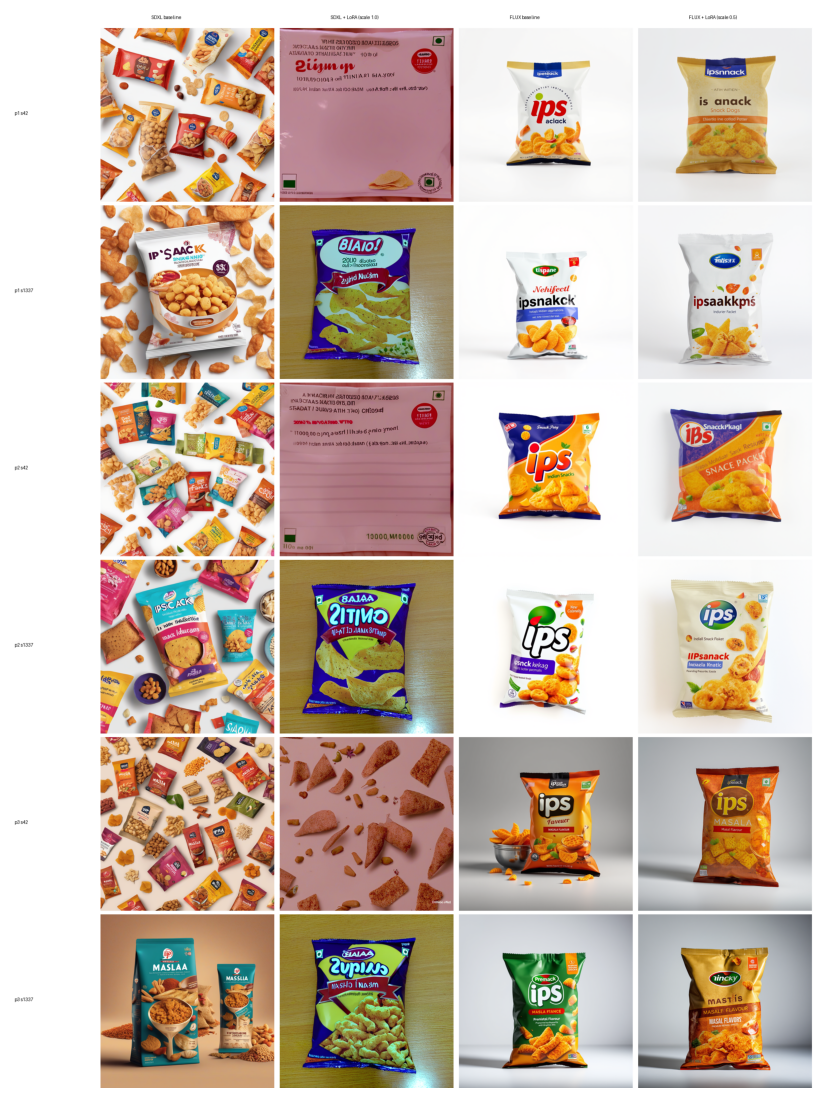

In [34]:
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont

# Output dir is where both SDXL and FLUX outputs live (same directory, different prefixes)
OUT = DRIVE_FLUX_OUT
print(f"Looking for outputs in: {OUT}")

# Helper that tries multiple filename conventions
def find_image(out_dir, model, variant, prompt_key, seed):
    candidates = [
        out_dir / f"{model}_{variant}_{prompt_key}_s{seed}.png",
        out_dir / f"{model}_{variant}_s{seed}.png",  # legacy: no prompt key
    ]
    for c in candidates:
        if c.exists():
            return c
    return None

thumb = 384
label_w = 200
col_gap = 12
header_h = 40

variants_per_model = [
    ("sdxl", "baseline", "SDXL baseline"),
    ("sdxl", "lora",     "SDXL + LoRA (scale 1.0)"),
    ("flux", "baseline", "FLUX baseline"),
    ("flux", "lora",     "FLUX + LoRA (scale 0.5)"),
]

rows = []
for pk in COMPARISON_PROMPTS:
    for seed in SEEDS:
        cells = []
        for model, variant, _ in variants_per_model:
            p = find_image(OUT, model, variant, pk, seed)
            cells.append(Image.open(p).resize((thumb, thumb)) if p else None)
        rows.append({"label": f"{pk} s{seed}", "cells": cells})

# Build canvas
n_rows = len(rows)
n_cols = len(variants_per_model)
canvas_w = label_w + n_cols * thumb + (n_cols - 1) * col_gap + 20
canvas_h = header_h + n_rows * thumb + (n_rows - 1) * 8
canvas = Image.new("RGB", (canvas_w, canvas_h), "white")
draw = ImageDraw.Draw(canvas)
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf", 16)
    font_small = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 13)
except Exception:
    font = font_small = ImageFont.load_default()

col_x = [label_w + i * (thumb + col_gap) for i in range(n_cols)]
for x, (_, _, title) in zip(col_x, variants_per_model):
    draw.text((x + thumb // 2 - 80, 10), title, fill="black", font=font)

y = header_h
for r in rows:
    draw.text((10, y + thumb // 2 - 10), r["label"], fill="black", font=font_small)
    for img, x in zip(r["cells"], col_x):
        if img is not None:
            canvas.paste(img, (x, y))
    y += thumb + 8

grid_path = OUT / "sdxl_vs_flux_comparison_v2.png"
canvas.save(grid_path)
print(f"\nComparison grid saved: {grid_path}")

# Diagnostic — show which images were found
print(f"\n{'Cell':<14} {'SDXL_base':>10} {'SDXL_LoRA':>10} {'FLUX_base':>10} {'FLUX_LoRA':>10}")
print("-" * 60)
for r in rows:
    marks = ["OK" if c else "—" for c in r["cells"]]
    print(f"{r['label']:<14} {marks[0]:>10} {marks[1]:>10} {marks[2]:>10} {marks[3]:>10}")

plt.figure(figsize=(16, 14))
plt.imshow(canvas); plt.axis("off"); plt.show()

In [35]:
import pandas as pd

# Just add the scale note as a column, don't rebuild
csv = DRIVE_ROOT / "evaluation" / "spike_flux_scores.csv"
df = pd.read_csv(csv)

# Annotate the operating scale per row for clarity during scoring
df["lora_scale"] = df.apply(
    lambda r: 1.0 if r["backbone"] == "sdxl" and r["condition"] == "lora"
              else 0.5 if r["backbone"] == "flux" and r["condition"] == "lora"
              else 0.0,
    axis=1,
)
df.to_csv(csv, index=False)
print(f"Annotated. Rows: {len(df)}")
print(df[["backbone", "condition", "lora_scale"]].drop_duplicates().to_string(index=False))

Annotated. Rows: 24
backbone condition  lora_scale
    flux  baseline         0.0
    flux      lora         0.5
    sdxl  baseline         0.0
    sdxl      lora         1.0


In [36]:
from pathlib import Path

DRIVE_ROOT = Path("/content/drive/MyDrive/dissertation")
checks = {
    "FLUX 1024 LoRA": DRIVE_ROOT / "outputs/lora_checkpoints/flux_packaging_lora_r16_res1024_steps2000.safetensors",
    "FLUX 512 LoRA":  DRIVE_ROOT / "outputs/lora_checkpoints/flux_packaging_lora_r16_res512_steps1000.safetensors",
    "Comparison v2":  DRIVE_ROOT / "outputs/flux_comparison/sdxl_vs_flux_comparison_v2.png",
    "Diagnostic grid": DRIVE_ROOT / "outputs/flux_comparison/_lora_diagnostic/diagnostic_grid.png",
    "Score scaffold": DRIVE_ROOT / "evaluation/spike_flux_scores.csv",
}
for label, p in checks.items():
    status = "✓" if p.exists() else "✗"
    size = f"{p.stat().st_size / 1e6:.1f} MB" if p.exists() else "MISSING"
    print(f"{status} {label}: {size}")

✓ FLUX 1024 LoRA: 89.7 MB
✓ FLUX 512 LoRA: 89.7 MB
✓ Comparison v2: 4.6 MB
✓ Diagnostic grid: 0.5 MB
✓ Score scaffold: 0.0 MB
